# Projeto de Data Science — Jogadores de Futebol
## Notebook 02 — Análise Exploratória de Dados (EDA)

---

### Objetivo
Investigar o dataset limpo (`players_clean.csv`) para descobrir padrões, entender
as relações entre as variáveis e **testar as hipóteses** que nortearão a modelagem.

### Hipóteses
- **H1 —** A relação entre a qualidade (overall) e o valor de mercado é
  **exponencial**, não linear.
- **H2 —** A idade tem efeito **não-linear** sobre o valor, com pico por volta dos 23 anos.
- **H3 —** Para um mesmo nível de overall, **atacantes valem mais** que defensores.
- **H4 —** Os atributos técnicos **separam naturalmente** os jogadores por setor de campo.


## 1. Configuração e carga dos dados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titleweight"] = "bold"

# Paleta consistente por setor de campo (usada em todo o notebook)
SETOR_CORES = {"Defensor": "#2471a3", "Meio-campo": "#16a085", "Atacante": "#c0392b"}
SETOR_ORDEM = ["Defensor", "Meio-campo", "Atacante"]

df = pd.read_csv("../data/players_clean.csv")
print(f"Dataset carregado: {df.shape[0]:,} jogadores x {df.shape[1]} colunas")
df.head(3)

Dataset carregado: 17,041 jogadores x 61 colunas


,sofifa_id,short_name,long_name,club_name,league_name,league_level,nationality_name,value_eur,wage_eur,age,height_cm,weight_kg,preferred_foot,weak_foot,skill_moves,international_reputation,work_rate,overall,potential,player_positions,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,pos_principal,field_sector,potential_gap,bmi,value_log,wage_log
0,158023,L. Messi,Lionel Andrés Messi Cuccittini,Paris Saint-Germain,French Ligue 1,1.00,Argentina,"78,000,000.00","320,000.00",34,170,72,Left,4,4,5,Medium/Low,93,93,"RW, ST, CF",85.00,92.00,91.00,95.00,34.00,65.00,85,95,70,91,88,96,93,94,91,96,91,80,91,94,95,86,68,72,69,94,44,40,93,95,75,96,20,35,24,RW,Atacante,0,24.91,18.17,12.68
1,188545,R. Lewandowski,Robert Lewandowski,FC Bayern München,German 1. Bundesliga,1.00,Poland,"119,500,000.00","270,000.00",32,185,81,Right,4,4,5,High/Medium,92,92,ST,78.00,92.00,79.00,86.00,44.00,82.00,71,95,90,85,89,85,79,85,70,88,77,79,77,93,82,90,85,76,86,87,81,49,95,81,90,88,35,42,19,ST,Atacante,0,23.67,18.60,12.51
2,20801,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,Manchester United,English Premier League,1.00,Portugal,"45,000,000.00","270,000.00",36,187,83,Right,4,5,5,High/Low,91,91,"ST, LW",87.00,94.00,80.00,88.00,34.00,75.00,87,95,90,80,86,88,81,84,77,88,85,88,86,94,74,94,95,77,77,93,63,29,95,76,88,95,24,32,24,ST,Atacante,0,23.74,17.62,12.51


## 2. Estatísticas descritivas

Um primeiro olhar sobre as principais variáveis numéricas.

In [2]:
cols_resumo = ["age", "overall", "potential", "potential_gap",
               "value_eur", "wage_eur", "pace", "shooting", "passing",
               "dribbling", "defending", "physic"]
df[cols_resumo].describe().T

,count,mean,std,min,25%,50%,75%,max
age,"17,041.00",25.07,4.61,16.00,21.00,25.00,28.00,39.00
overall,"17,041.00",65.93,6.77,47.00,62.00,66.00,70.00,93.00
potential,"17,041.00",71.24,6.05,49.00,67.00,71.00,75.00,95.00
potential_gap,"17,041.00",5.31,5.52,0.00,0.00,4.00,9.00,25.00
value_eur,"17,041.00","2,965,082.15","7,717,023.54","15,000.00","525,000.00","1,000,000.00","2,100,000.00","194,000,000.00"
wage_eur,"17,041.00","9,354.73","19,880.72",500.00,"1,000.00","3,000.00","9,000.00","350,000.00"
pace,"17,041.00",68.24,10.91,28.00,62.00,69.00,76.00,97.00
shooting,"17,041.00",52.33,14.05,18.00,42.00,54.00,63.00,94.00
passing,"17,041.00",57.30,10.07,25.00,51.00,58.00,64.00,93.00
dribbling,"17,041.00",62.56,9.65,27.00,57.00,64.00,69.00,95.00


Pontos de destaque:
- O **overall** médio gira em torno de 65–66, com distribuição aproximadamente normal.
- O **valor de mercado** tem média muito maior que a mediana — sinal claro de
  forte assimetria (poucos jogadores muito caros puxando a média).
- A **idade** concentra-se na faixa dos 20 aos 30 anos.

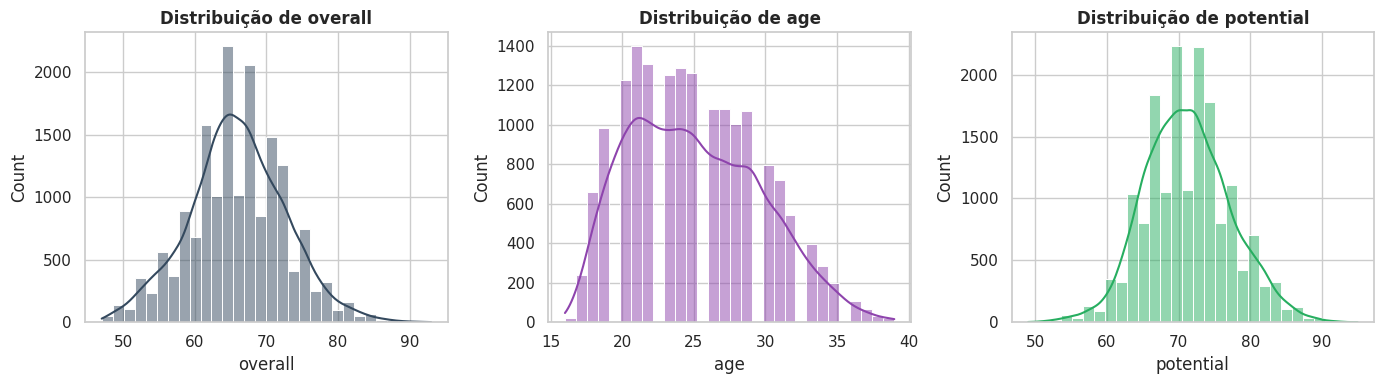

In [3]:
# Distribuições das variáveis de perfil
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, cor in zip(axes, ["overall", "age", "potential"],
                        ["#34495e", "#8e44ad", "#27ae60"]):
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color=cor)
    ax.set_title(f"Distribuição de {col}")
plt.tight_layout()
plt.show()

## 3. Hipótese H1 — Overall × Valor de mercado

Comparamos o valor de mercado contra o overall em **duas escalas**: a original e a
logarítmica. Se a relação for de fato exponencial, ela aparecerá **curva** na
escala original e aproximadamente **reta** na escala logarítmica.

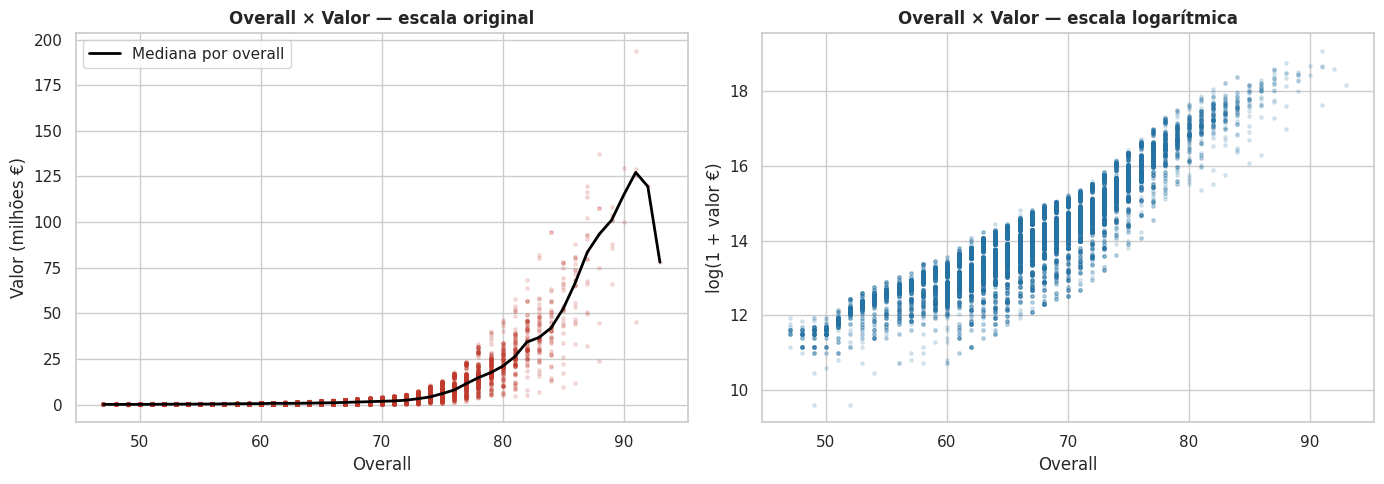

Correlação overall × valor (original): 0.564
Correlação overall × valor (log):      0.906


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Escala original
axes[0].scatter(df["overall"], df["value_eur"] / 1e6, s=6, alpha=0.15, color="#c0392b")
mediana_por_overall = df.groupby("overall")["value_eur"].median() / 1e6
axes[0].plot(mediana_por_overall.index, mediana_por_overall.values,
             color="black", lw=2, label="Mediana por overall")
axes[0].set_xlabel("Overall"); axes[0].set_ylabel("Valor (milhões €)")
axes[0].set_title("Overall × Valor — escala original"); axes[0].legend()

# Escala logarítmica
axes[1].scatter(df["overall"], df["value_log"], s=6, alpha=0.15, color="#2471a3")
axes[1].set_xlabel("Overall"); axes[1].set_ylabel("log(1 + valor €)")
axes[1].set_title("Overall × Valor — escala logarítmica")

plt.tight_layout(); plt.show()

print(f"Correlação overall × valor (original): {df['overall'].corr(df['value_eur']):.3f}")
print(f"Correlação overall × valor (log):      {df['overall'].corr(df['value_log']):.3f}")

**H1 confirmada.** Na escala original a relação é claramente curva (o valor
"explode" a partir de overall ~80), enquanto na escala logarítmica ela se torna
quase linear. A correlação sobe expressivamente ao usar o log, mostrando que
**`value_log` é a forma adequada do alvo** para modelos lineares.

## 4. Hipótese H2 — Efeito da idade sobre o valor

Calculamos o valor **mediano** por idade (a mediana é robusta aos outliers de
preço). Se a hipótese estiver correta, veremos uma curva que sobe, atinge um pico
no início/meio dos 20 e depois cai.

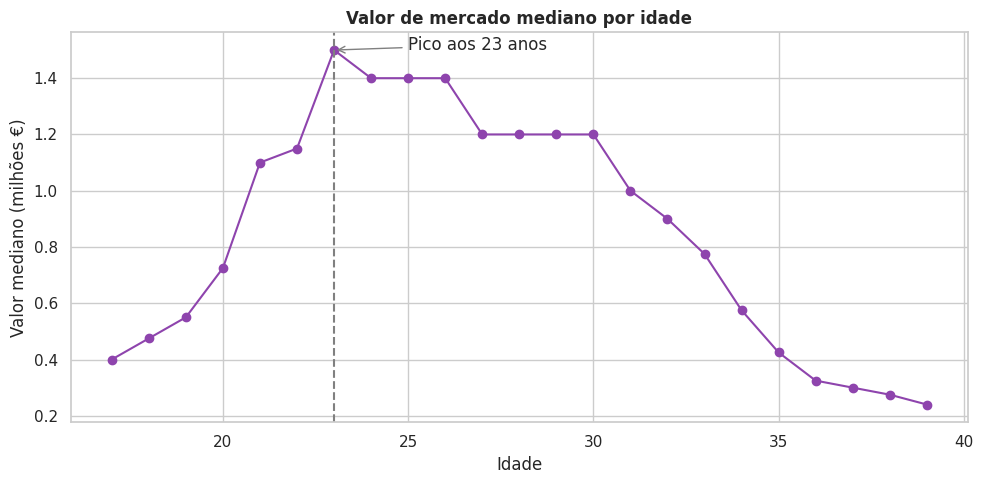

In [5]:
# Considera apenas idades com amostra razoável para evitar ruído nas pontas
contagem_idade = df["age"].value_counts()
idades_validas = contagem_idade[contagem_idade >= 20].index
sub = df[df["age"].isin(idades_validas)]

valor_por_idade = sub.groupby("age")["value_eur"].median() / 1e6

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(valor_por_idade.index, valor_por_idade.values, marker="o", color="#8e44ad")
pico = valor_por_idade.idxmax()
ax.axvline(pico, ls="--", color="gray")
ax.annotate(f"Pico aos {pico} anos", xy=(pico, valor_por_idade.max()),
            xytext=(pico + 2, valor_por_idade.max()),
            arrowprops=dict(arrowstyle="->", color="gray"))
ax.set_xlabel("Idade"); ax.set_ylabel("Valor mediano (milhões €)")
ax.set_title("Valor de mercado mediano por idade")
plt.tight_layout(); plt.show()

**H2 confirmada.** O valor cresce rapidamente no início dos 20 anos, atinge o
**pico por volta dos 23 anos** e mantém-se elevado até cerca dos 27 (auge
físico-técnico aliado a tempo de carreira pela frente), decaindo de forma
consistente depois — refletindo a menor janela de contrato e a queda de
desempenho esperada. A relação é nitidamente **não-linear**, o que será relevante
na interpretação dos modelos lineares.

## 5. Hipótese H3 — Valor por setor de campo

Primeiro a visão geral (valor por setor) e, em seguida, o teste **controlando
pelo overall**: comparamos o valor mediano de cada setor *dentro de uma mesma
faixa de overall*. Só assim conseguimos isolar o efeito da posição do efeito da
qualidade.

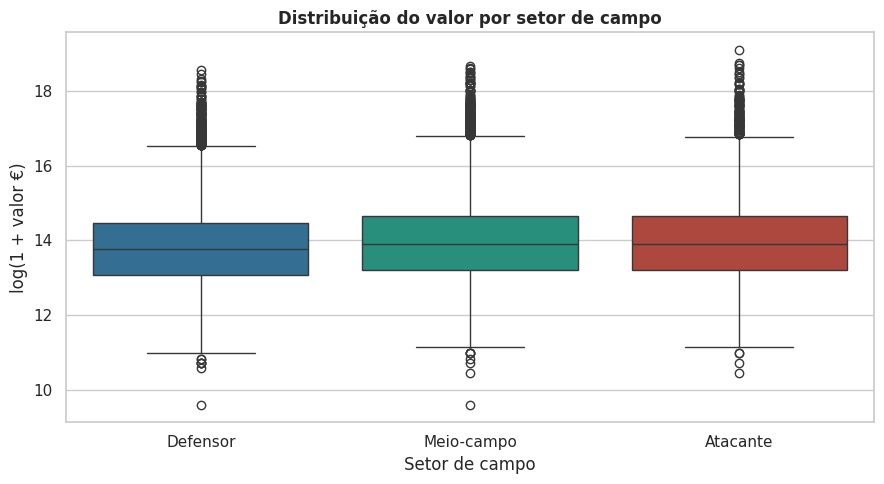

In [6]:
# 5.1 Visão geral: valor (log) por setor
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="field_sector", y="value_log", order=SETOR_ORDEM,
            hue="field_sector", palette=SETOR_CORES, legend=False, ax=ax)
ax.set_xlabel("Setor de campo"); ax.set_ylabel("log(1 + valor €)")
ax.set_title("Distribuição do valor por setor de campo")
plt.tight_layout(); plt.show()

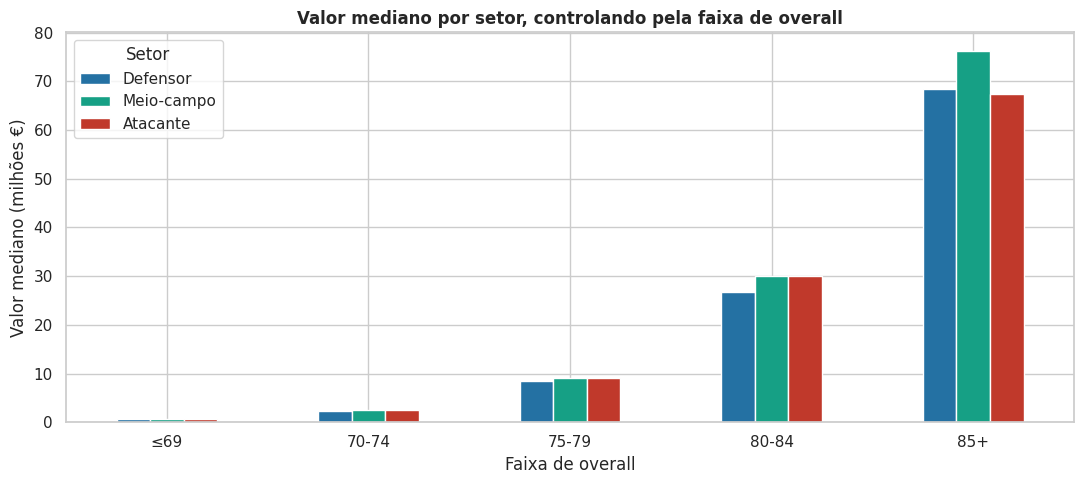

field_sector   Defensor  Meio-campo  Atacante
faixa_overall                                
≤69                0.70        0.75      0.72
70-74              2.30        2.60      2.50
75-79              8.50        9.00      9.00
80-84             26.75       30.00     30.00
85+               68.50       76.25     67.50


In [7]:
# 5.2 Controlando pelo overall: valor mediano por faixa de overall e setor
faixas = pd.cut(df["overall"], bins=[0, 69, 74, 79, 84, 100],
                labels=["≤69", "70-74", "75-79", "80-84", "85+"])
tabela = (df.assign(faixa_overall=faixas)
            .groupby(["faixa_overall", "field_sector"], observed=True)["value_eur"]
            .median().div(1e6).unstack())[SETOR_ORDEM]

ax = tabela.plot(kind="bar", figsize=(11, 5),
                 color=[SETOR_CORES[s] for s in SETOR_ORDEM])
ax.set_xlabel("Faixa de overall"); ax.set_ylabel("Valor mediano (milhões €)")
ax.set_title("Valor mediano por setor, controlando pela faixa de overall")
ax.legend(title="Setor"); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

print(tabela.round(2))

**H3 refutada como formulada — e o resultado é mais interessante que a
hipótese.** Controlando pelo overall, vê-se que o "prêmio" de valor **não é dos
atacantes, e sim dos meio-campistas**, que lideram o valor mediano em quase todas
as faixas. Os defensores são os menos valorizados nas faixas intermediárias
(70–84), mas na elite (overall 85+) eles **se equiparam aos atacantes** — que,
nesse topo, não exibem qualquer prêmio sobre os defensores. Ou seja, a vantagem
ofensiva que supúnhamos não se sustenta; o que existe é uma leve valorização do
meio-campo, modesta diante do efeito dominante do overall.

## 6. Hipótese H4 — Atributos técnicos separam os jogadores por posição

### 6.1. Perfil de atributos por setor
Padronizamos os 6 atributos agregados (média 0, desvio 1) e calculamos a média de
cada setor. Valores positivos (vermelho) indicam que o setor está **acima** da
média geral naquele atributo.

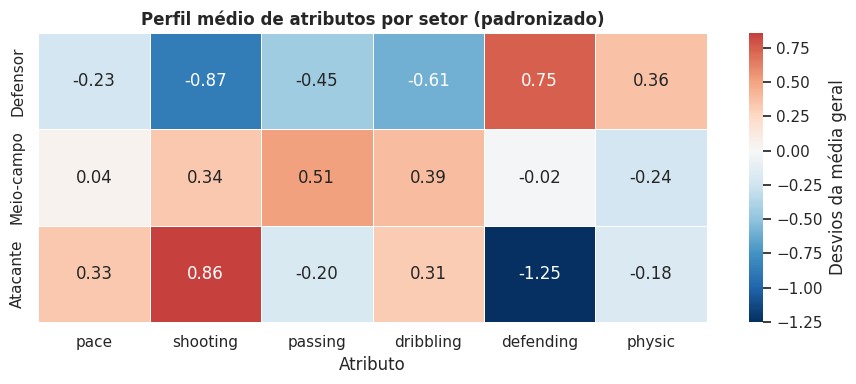

In [8]:
attrs_agg = ["pace", "shooting", "passing", "dribbling", "defending", "physic"]
z = (df[attrs_agg] - df[attrs_agg].mean()) / df[attrs_agg].std()
perfil_setor = z.groupby(df["field_sector"]).mean().loc[SETOR_ORDEM]

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(perfil_setor, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.5, ax=ax, cbar_kws={"label": "Desvios da média geral"})
ax.set_title("Perfil médio de atributos por setor (padronizado)")
ax.set_xlabel("Atributo"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

O padrão é exatamente o esperado pelo conhecimento de futebol: **defensores**
se destacam em `defending` e `physic`; **atacantes** em `shooting`, `pace` e
`dribbling`; **meio-campistas** em `passing`. Isso sugere forte separabilidade.

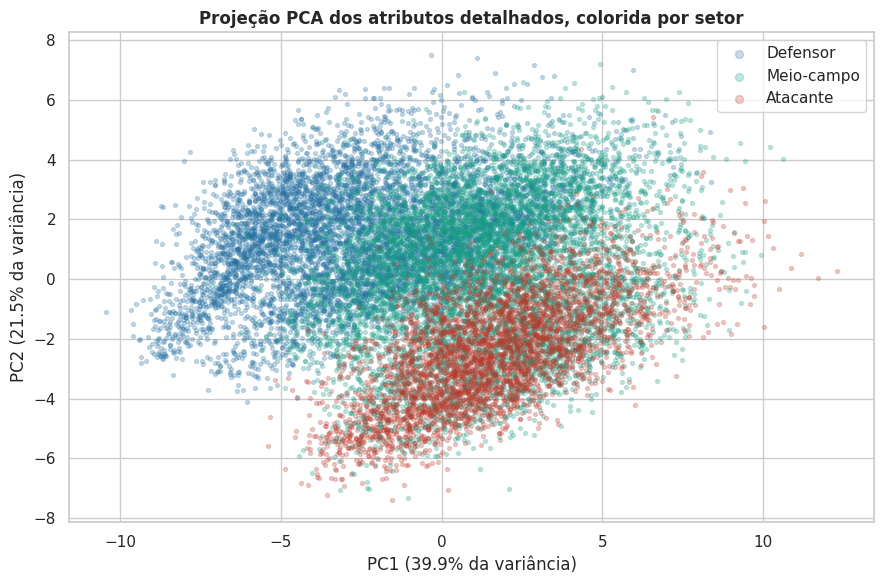

Variância explicada por PC1+PC2: 61.4%


In [9]:
# 6.2. Prévia da separabilidade via PCA (2 componentes) sobre os 29 atributos detalhados
attrs_det = [c for c in df.columns if c.startswith(
    ("attacking_", "skill_", "movement_", "power_", "mentality_", "defending_"))]

X = StandardScaler().fit_transform(df[attrs_det])
pca = PCA(n_components=2, random_state=42)
comp = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(9, 6))
for setor in SETOR_ORDEM:
    m = df["field_sector"].values == setor
    ax.scatter(comp[m, 0], comp[m, 1], s=8, alpha=0.25,
               color=SETOR_CORES[setor], label=setor)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% da variância)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% da variância)")
ax.set_title("Projeção PCA dos atributos detalhados, colorida por setor")
ax.legend(markerscale=2)
plt.tight_layout(); plt.show()

print(f"Variância explicada por PC1+PC2: {pca.explained_variance_ratio_[:2].sum()*100:.1f}%")

**H4 confirmada.** Mesmo reduzindo 29 atributos a apenas 2 dimensões, os setores
formam regiões visualmente distintas. Isso é um forte indício de que o **K-Means
conseguirá recuperar grupos correspondentes às posições** — exatamente o que
investigaremos no notebook de modelagem. Note também que padronizamos os
atributos antes do PCA: como essas técnicas se baseiam em distância/variância,
a padronização é indispensável.

## 7. Correlações com o valor de mercado

Quais variáveis estão mais associadas ao valor (em log)?

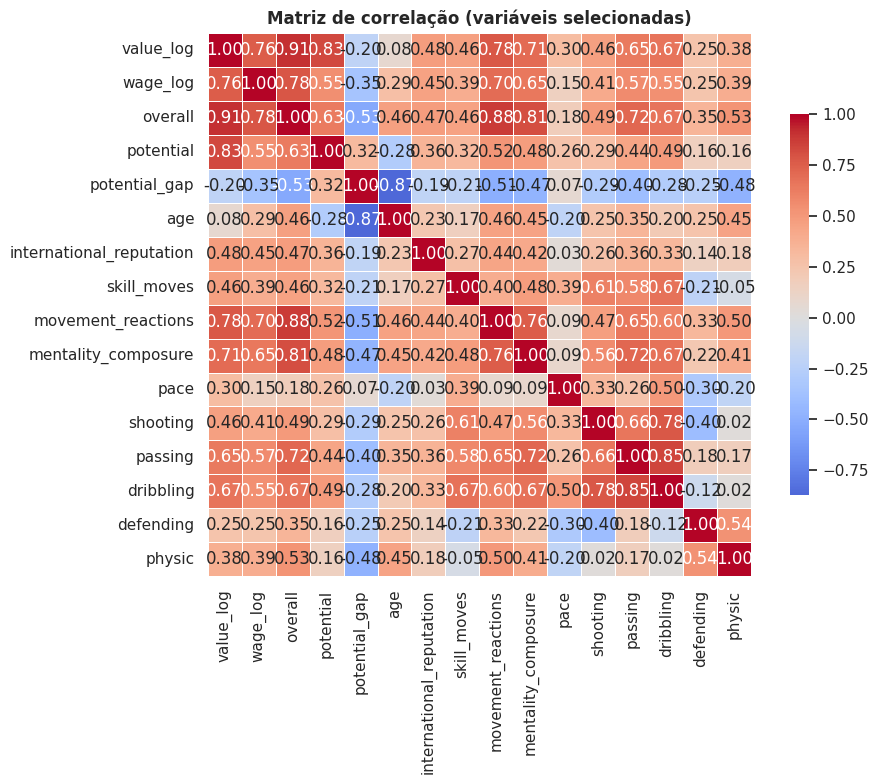

In [10]:
cols_corr = ["value_log", "wage_log", "overall", "potential", "potential_gap",
             "age", "international_reputation", "skill_moves",
             "movement_reactions", "mentality_composure"] + attrs_agg

corr = df[cols_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("Matriz de correlação (variáveis selecionadas)")
plt.tight_layout(); plt.show()

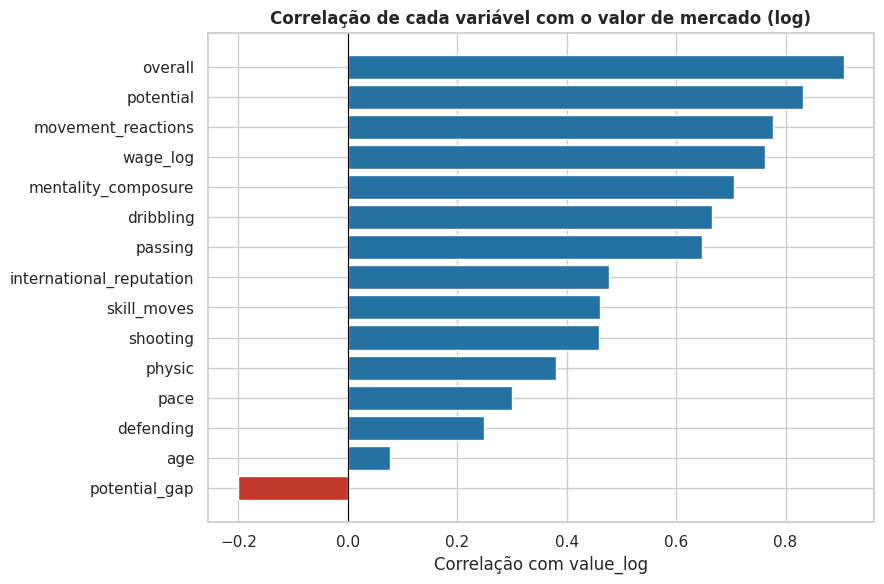

potential_gap              -0.20
age                         0.08
defending                   0.25
pace                        0.30
physic                      0.38
shooting                    0.46
skill_moves                 0.46
international_reputation    0.48
passing                     0.65
dribbling                   0.67
mentality_composure         0.71
wage_log                    0.76
movement_reactions          0.78
potential                   0.83
overall                     0.91
Name: value_log, dtype: float64


In [11]:
# Ranking de correlação com o valor (log)
corr_valor = (df[cols_corr].corr()["value_log"]
              .drop("value_log").sort_values())
fig, ax = plt.subplots(figsize=(9, 6))
cores = ["#c0392b" if v < 0 else "#2471a3" for v in corr_valor.values]
ax.barh(corr_valor.index, corr_valor.values, color=cores)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Correlação com value_log")
ax.set_title("Correlação de cada variável com o valor de mercado (log)")
plt.tight_layout(); plt.show()
print(corr_valor.round(3))

**Leitura para a modelagem:**
- `overall` (0,91) e `potential` (0,83) são, de longe, os preditores mais fortes
  do valor — fazem sentido, pois resumem a qualidade do jogador. Em seguida vêm
  `movement_reactions` e `mentality_composure`, atributos que sintetizam
  "inteligência de jogo".
- A **idade** tem correlação **linear** próxima de zero (+0,08). Isso **não
  contradiz a H2 — pelo contrário, reforça-a**: como a relação idade×valor é uma
  curva (sobe e desce), o coeficiente linear praticamente se anula. É um bom
  lembrete de que a correlação linear não enxerga efeitos não-lineares.
- `potential_gap` é negativo (−0,20): jogadores jovens com muita margem de
  evolução ainda valem pouco *hoje*.
- `wage_log` tem correlação altíssima com o valor. **Atenção:** salário e valor
  são determinados conjuntamente pelo mercado — usar o salário para prever o valor
  configuraria um *near-leakage*. Por isso, na modelagem, **não usaremos `wage_eur`
  como preditor**; ele fica apenas como variável exploratória.
- Vários atributos são muito correlacionados entre si (multicolinearidade), o que
  afeta a interpretação dos coeficientes da regressão linear — voltaremos a isso.

## 8. Alguns insights adicionais

In [12]:
# Top 10 jogadores mais valiosos
top10 = df.nlargest(10, "value_eur")[
    ["short_name", "club_name", "field_sector", "age", "overall", "value_eur"]]
top10["value_eur"] = (top10["value_eur"] / 1e6).round(1)
top10 = top10.rename(columns={"value_eur": "valor (M€)"})
print("Top 10 jogadores mais valiosos:")
top10.reset_index(drop=True)

Top 10 jogadores mais valiosos:


,short_name,club_name,field_sector,age,overall,valor (M€)
0,K. Mbappé,Paris Saint-Germain,Atacante,22,91,194.00
1,E. Haaland,Borussia Dortmund,Atacante,20,88,137.50
2,H. Kane,Tottenham Hotspur,Atacante,27,90,129.50
3,Neymar Jr,Paris Saint-Germain,Atacante,29,91,129.00
4,K. De Bruyne,Manchester City,Meio-campo,30,91,125.50
5,R. Lewandowski,FC Bayern München,Atacante,32,92,119.50
6,F. de Jong,FC Barcelona,Meio-campo,24,87,119.50
7,J. Sancho,Manchester United,Meio-campo,21,87,116.50
8,T. Alexander-Arnold,Liverpool,Defensor,22,87,114.00
9,J. Kimmich,FC Bayern München,Meio-campo,26,89,108.00


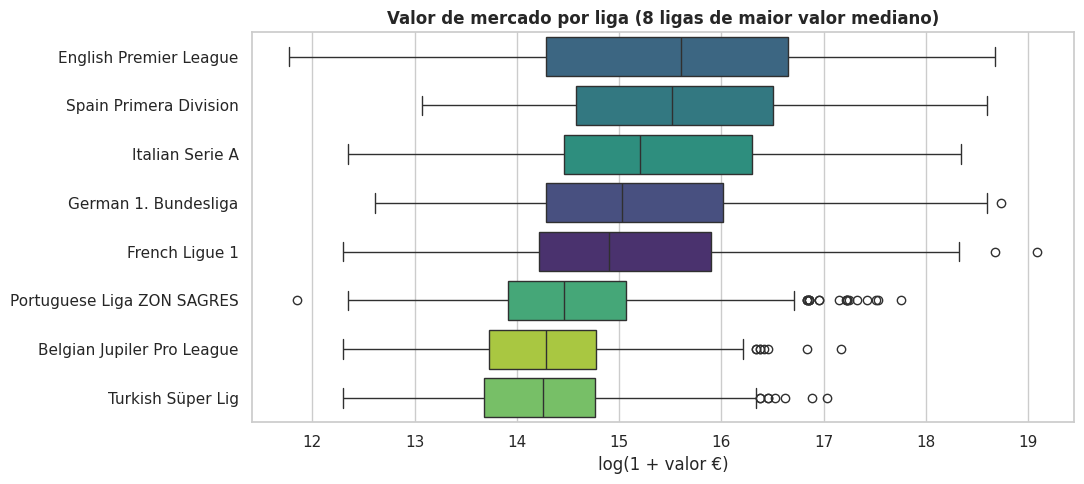

In [13]:
# Valor por liga (top 8 ligas com mais jogadores entre as de maior valor mediano)
ligas_grandes = df["league_name"].value_counts().head(20).index
sub_liga = df[df["league_name"].isin(ligas_grandes)]
ordem_liga = (sub_liga.groupby("league_name")["value_eur"].median()
              .sort_values(ascending=False).head(8).index)

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=sub_liga[sub_liga["league_name"].isin(ordem_liga)],
            x="value_log", y="league_name", order=ordem_liga,
            hue="league_name", palette="viridis", legend=False, ax=ax)
ax.set_xlabel("log(1 + valor €)"); ax.set_ylabel("")
ax.set_title("Valor de mercado por liga (8 ligas de maior valor mediano)")
plt.tight_layout(); plt.show()

As grandes ligas europeias (Premier League, La Liga, Bundesliga, Serie A)
concentram os jogadores de maior valor — um efeito de mercado que pode ser
explorado como variável categórica na modelagem.

---
### Resumo da EDA
| Hipótese | Resultado |
|---|---|
| **H1** — relação overall×valor exponencial | ✅ Confirmada (linear no log) |
| **H2** — efeito não-linear da idade | ✅ Confirmada (pico ~23 anos, platô até ~27) |
| **H3** — atacantes valem mais (mesmo overall) | 🔴 Refutada: o prêmio é do meio-campo, não do ataque |
| **H4** — atributos separam por posição | ✅ Confirmada (heatmap + PCA) |

**Decisões levadas para a modelagem (`03_modelagem.ipynb`):**
1. Prever `value_log` (não o valor bruto).
2. **Não usar `wage_eur`** como preditor (near-leakage).
3. Usar idade, overall, potential, reputação e os atributos técnicos como features.
4. Atenção à multicolinearidade na interpretação da Regressão Linear.
5. A boa separabilidade por setor (H4) sustenta a aplicação do **K-Means**.
